In [1]:
import torch

In [2]:

words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join([ w.strip() for w in  words]))))
chars = ['.'] + chars
stoi = { ch : i for i, ch in enumerate(chars) }
itos = {i: ch for ch, i in stoi.items()}


In [4]:
print(len(words))

min(len(w) for w in words)

32033


2

In [5]:
max(len(w) for w in words)

15

In [6]:


N = torch.ones(27, 27, dtype = torch.int32)
for w in words:
    w = '.' + w + '.'
    for ch1, ch2 in zip(w, w[1:]):
        x1 = stoi[ch1]
        x2 = stoi[ch2]
        #print(ch1, ch2)
        N[x1, x2] += 1
    

p = N.float() / N.sum(dim= 1 , keepdim= True)
p[0]




tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

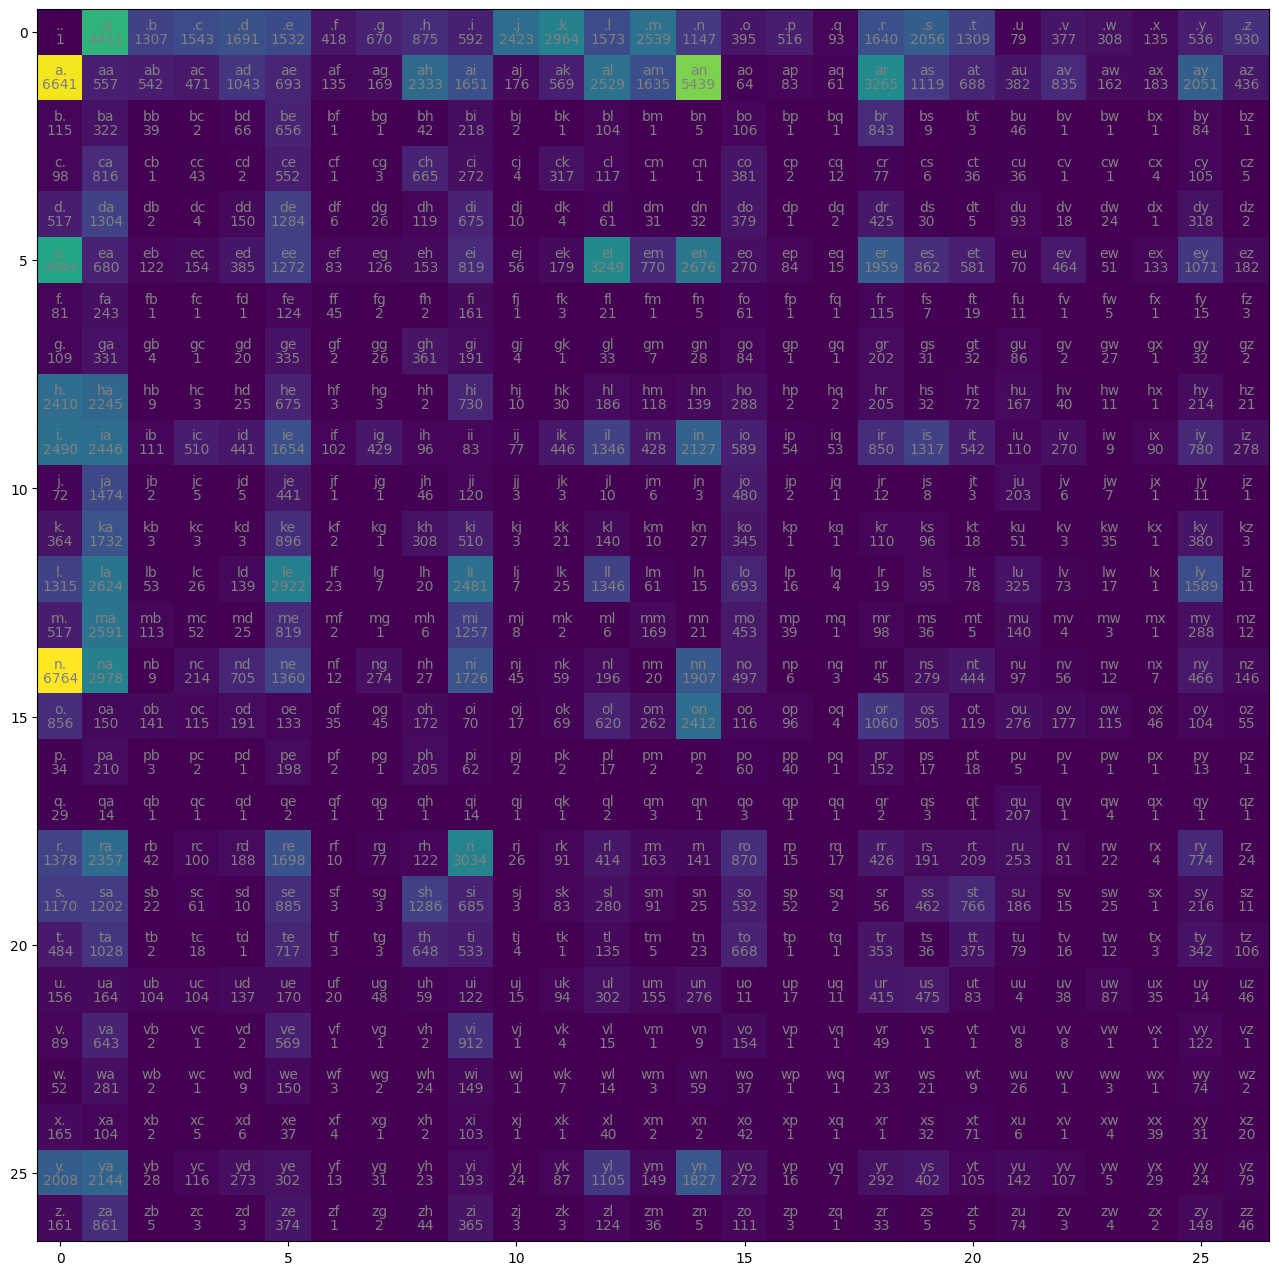

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N)
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = "grey")
        plt.text(j, i , N[i, j].item(), ha = "center", va = "top", color = "grey")

In [8]:
torch.__version__

'2.11.0+cpu'

In [9]:
p = N[0].float()
p = p / p.sum()
p

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

In [10]:
g = torch.Generator().manual_seed(2147483647)

p = N.float() / N.sum(dim= 1 , keepdim=True)

for i in range(10):
    ix = 0
    out = []
    while True:
      ix = torch.multinomial(p[ix], num_samples= 1 , replacement=True, generator= g).item()
      out.append(ix)
      if ix == 0:
         break
    print( ''.join(itos[i] for i in out ) )

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [16]:
from torch.nn import functional as F
w = torch.randn(27,27, requires_grad=True)

x = []
y = []
for word in words:
    word = '.' + word + '.'
    for ch1, ch2 in zip(word, word[1:]):
        x1 = stoi[ch1]
        x2 = stoi[ch2]
        #print(ch1, ch2)
        x.append(x1)
        y.append(x2)
xs = torch.tensor(x)
num = xs.nelement()
xenc = F.one_hot(xs, num_classes=27).float()

y = torch.tensor(y)

In [50]:
y.shape

torch.Size([228146])

In [ ]:


for i in range(100):
    logits = xenc @ w
    counts = logits.exp()
    p = counts / counts.sum(dim= 1 , keepdim= True)

    loss = - p[torch.arange(num),y].log().mean()
    # 2. Backward pass
    w.grad = None # Zero out gradients from last time
    loss.backward()

    # 3. Update weights
    w.data += -10 * w.grad
print(loss.item())








2.4911599159240723
2.491022825241089
2.490886688232422
2.490751266479492
2.490616798400879
2.490483283996582
2.4903504848480225
2.4902186393737793
2.4900877475738525
2.489957809448242


In [64]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    ix = 0
    out = []
    while True:
      ix = torch.multinomial(p[ix], num_samples= 1 , replacement=True, generator= g).item()
      out.append(ix)
      if ix == 0:
         break
    print( ''.join(itos[i] for i in out ) )

cexba.
mhalkuraiiaziayhnekljlmjtraierlknan.
kh.
dr.
snaiiaebjtrhr.
gotas.
mdziedlkvu.
k.
pted.
jek.


In [14]:
torch.multinomial(p, num_samples= 100 , replacement=True, generator= g)

tensor([[12,  8, 13,  ..., 16, 10, 25],
        [ 8, 19,  2,  ..., 18, 21,  1],
        [ 8, 19, 12,  ...,  4,  3, 12],
        ...,
        [15,  6, 11,  ..., 17, 26, 11],
        [14, 16, 17,  ..., 13, 14,  5],
        [ 0, 21,  0,  ..., 13, 21, 23]])

AttributeError: module 'torch' has no attribute 'one'